# Deliverable 4: Final Insights, Recommendations, and Presentation

## Advanced Data Mining Project

Dataset: `ecommerce_user_dataset_cleaned.csv`

This notebook consolidates the end-to-end project journey:

- Dataset context and motivation
- Data preparation, EDA, and feature engineering recap
- Regression, classification, clustering, and association rule results
- Practical recommendations and ethical considerations
- A 5-7 minute presentation outline


In [ ]:
# Optional install helper for first-time environments
# Uncomment and run if any package import fails.
# %pip install numpy pandas matplotlib seaborn scikit-learn mlxtend

In [ ]:
# Core imports
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False


print('Environment ready. Seaborn available:', HAS_SEABORN)

Environment ready. Seaborn available: True


## 1) Dataset and Selection Rationale

The e-commerce dataset contains 1,000 records with behavioral and transactional attributes.

Why selected:

- Satisfies project size and dimensionality requirements
- Supports both supervised and unsupervised mining tasks
- Includes a segment label for classification while preserving rich continuous features


In [2]:
# Load dataset
df = pd.read_csv('ecommerce_user_dataset_cleaned.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())
display(df.describe(include='all').T)

Shape: (1000, 8)
Columns: ['Customer_ID', 'Purchase_History', 'Transaction_Frequency', 'Monetary_Value', 'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site', 'Customer_Segment']


,Customer_ID,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,Customer_Segment
0,CUST0001,23,0.2577,664.0900,88.1000,0.2600,11.8400,Iron
1,CUST0002,15,0.3785,"4,244.2100",5.8700,0.2800,35.0400,Copp
2,CUST0003,21,2.5781,"4,638.4700",23.8800,0.9300,10.1400,Copp
3,CUST0004,25,1.7498,"7,277.5600",89.8400,0.0200,22.0200,Iron
4,CUST0005,15,1.3223,"5,785.4500",26.3600,0.7000,42.1200,Copp


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,1000,1000,CUST0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_History,"1,000.0000",NaN,NaN,NaN,19.8790,4.5615,8.0000,17.0000,20.0000,23.0000,32.0000
Transaction_Frequency,"1,000.0000",NaN,NaN,NaN,4.6869,4.1306,0.0001,1.4262,3.4695,6.8135,14.8943
Monetary_Value,"1,000.0000",NaN,NaN,NaN,"4,926.2117","2,819.0933",100.3000,"2,455.9975","4,890.7250","7,311.5775","9,995.6200"
Browsing_Behavior,"1,000.0000",NaN,NaN,NaN,50.2197,28.4882,1.0200,25.9775,48.7500,75.3825,99.8800
Engagement_Score,"1,000.0000",NaN,NaN,NaN,0.4997,0.2927,0.0000,0.2400,0.5000,0.7600,1.0000
Time_on_Site,"1,000.0000",NaN,NaN,NaN,29.8492,16.7392,1.0100,15.4925,29.3800,44.1450,59.9500
Customer_Segment,1000,2,Copp,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2) Data Preparation, EDA, and Feature Engineering

This section summarizes cleaning quality checks and introduces engineered features used across models.


Missing values per column:
Customer_ID              0
Purchase_History         0
Transaction_Frequency    0
Monetary_Value           0
Browsing_Behavior        0
Engagement_Score         0
Time_on_Site             0
Customer_Segment         0
dtype: int64

Duplicate rows: 0
Invalid Engagement_Score values: 0
Invalid Time_on_Site values: 0


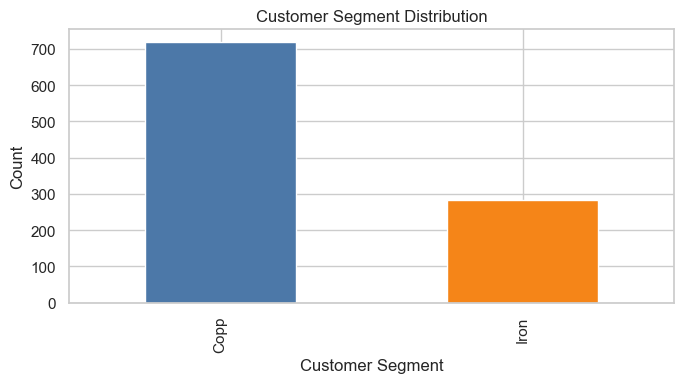

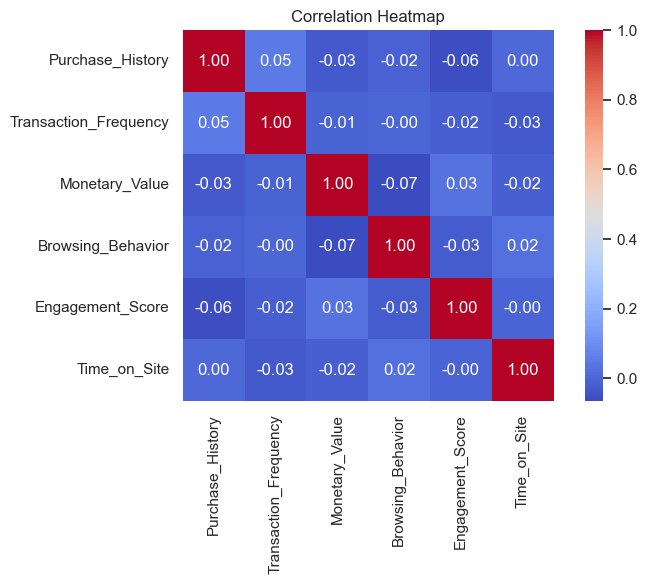

In [ ]:
# Basic data quality checks
missing_counts = df.isna().sum()
duplicate_count = df.duplicated().sum()
invalid_engagement = ((df['Engagement_Score'] < 0) |
                      (df['Engagement_Score'] > 1)).sum()
invalid_time = (df['Time_on_Site'] < 0).sum()

print('Missing values per column:')
print(missing_counts)
print('\nDuplicate rows:', duplicate_count)
print('Invalid Engagement_Score values:', invalid_engagement)
print('Invalid Time_on_Site values:', invalid_time)

# Shared feature engineering used in Deliverables 2 and 3
df_model = df.copy()
df_model['purchase_freq_interaction'] = df_model['Purchase_History'] * \
    df_model['Transaction_Frequency']
df_model['engagement_time_interaction'] = df_model['Engagement_Score'] * \
    df_model['Time_on_Site']
df_model['browsing_per_visit'] = df_model['Browsing_Behavior'] / \
    (df_model['Transaction_Frequency'] + 1)
df_model['purchase_per_visit'] = df_model['Purchase_History'] / \
    (df_model['Transaction_Frequency'] + 1)

num_cols = [
    'Purchase_History', 'Transaction_Frequency', 'Monetary_Value',
    'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site'
]

plt.figure(figsize=(7, 4))
segment_counts = df_model['Customer_Segment'].value_counts()
segment_counts.plot(kind='bar', color=['#4C78A8', '#F58518'])
plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
corr = df_model[num_cols].corr(numeric_only=True)
if HAS_SEABORN:
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
else:
    plt.imshow(corr, cmap='coolwarm', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
    plt.yticks(range(len(num_cols)), num_cols)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3) Regression Results (Deliverable 2 Summary)


In [ ]:
# Regression target and features
target_reg = 'Monetary_Value'
num_features_reg = [
    'Purchase_History', 'Transaction_Frequency', 'Browsing_Behavior',
    'Engagement_Score', 'Time_on_Site', 'purchase_freq_interaction',
    'engagement_time_interaction', 'browsing_per_visit', 'purchase_per_visit'
]
cat_features_reg = ['Customer_Segment']

X_reg = df_model[num_features_reg + cat_features_reg]
y_reg = df_model[target_reg]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

num_pipe = Pipeline(
    [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

pre_reg = ColumnTransformer(
    [('num', num_pipe, num_features_reg), ('cat', cat_pipe, cat_features_reg)])

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42)
}

reg_rows = []
for name, model in reg_models.items():
    pipe = Pipeline([('preprocessor', pre_reg), ('model', model)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)

    mse = mean_squared_error(yr_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yr_test, pred)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_validate(pipe, X_reg, y_reg, cv=cv, scoring={
                               'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'})

    reg_rows.append({
        'Model': name,
        'Test_R2': r2,
        'Test_RMSE': rmse,
        'CV_R2_Mean': cv_scores['test_r2'].mean(),
        'CV_RMSE_Mean': -cv_scores['test_rmse'].mean()
    })

reg_results = pd.DataFrame(reg_rows).sort_values(
    'CV_RMSE_Mean').reset_index(drop=True)
display(reg_results)

,Model,Test_R2,Test_RMSE,CV_R2_Mean,CV_RMSE_Mean
0,Ridge,0.2055,"2,436.4375",0.2130,"2,493.0661"
1,Lasso,0.2053,"2,436.6336",0.2129,"2,493.3083"
2,LinearRegression,0.2053,"2,436.6331",0.2129,"2,493.3086"


## 4) Classification, Clustering, and Pattern Mining Results (Deliverable 3 Summary)


,Model,Accuracy,F1_Score
0,DecisionTree,1.0000,1.0000
1,TunedKNN,0.8800,0.7692


DecisionTree Confusion Matrix
[[144   0]
 [  0  56]]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       144
           1     1.0000    1.0000    1.0000        56

    accuracy                         1.0000       200
   macro avg     1.0000    1.0000    1.0000       200
weighted avg     1.0000    1.0000    1.0000       200

TunedKNN Confusion Matrix
[[136   8]
 [ 16  40]]
              precision    recall  f1-score   support

           0     0.8947    0.9444    0.9189       144
           1     0.8333    0.7143    0.7692        56

    accuracy                         0.8800       200
   macro avg     0.8640    0.8294    0.8441       200
weighted avg     0.8775    0.8800    0.8770       200



<Figure size 800x600 with 0 Axes>

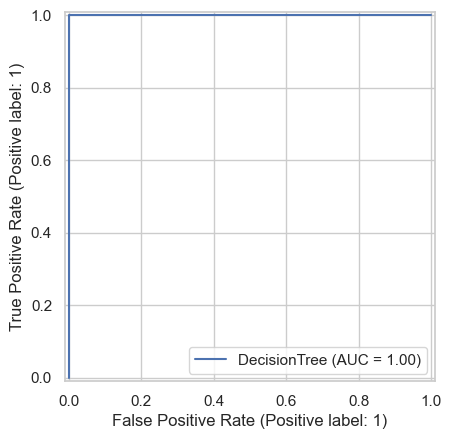

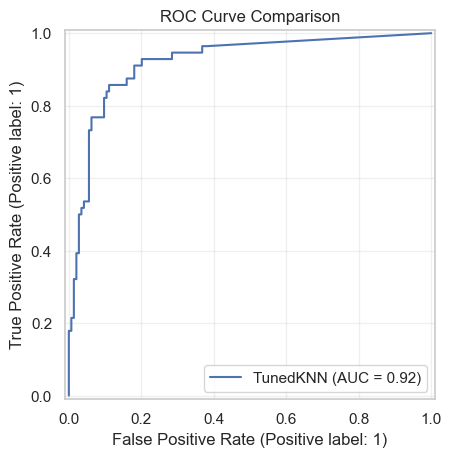

In [ ]:
# Classification setup
segment_order = sorted(df_model['Customer_Segment'].dropna().unique().tolist())
segment_map = {segment_order[0]: 0, segment_order[1]: 1}
df_model['Target_Binary'] = df_model['Customer_Segment'].map(segment_map)

feature_cols_clf = [
    'Purchase_History', 'Transaction_Frequency', 'Monetary_Value',
    'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site',
    'purchase_freq_interaction', 'engagement_time_interaction',
    'browsing_per_visit', 'purchase_per_visit'
]

X_clf = df_model[feature_cols_clf]
y_clf = df_model['Target_Binary']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

pre_clf = ColumnTransformer([('num', Pipeline([('imputer', SimpleImputer(
    strategy='median')), ('scaler', StandardScaler())]), feature_cols_clf)])

tree_pipe = Pipeline([('preprocessor', pre_clf), ('model',
                     DecisionTreeClassifier(random_state=42, max_depth=5))])
knn_pipe = Pipeline(
    [('preprocessor', pre_clf), ('model', KNeighborsClassifier())])

grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid={'model__n_neighbors': [3, 5, 7, 9, 11], 'model__weights': [
        'uniform', 'distance'], 'model__metric': ['euclidean', 'manhattan']},
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(Xc_train, yc_train)
best_knn = grid.best_estimator_

tree_pipe.fit(Xc_train, yc_train)

clf_models = {'DecisionTree': tree_pipe, 'TunedKNN': best_knn}
clf_rows = []
clf_pred = {}
clf_proba = {}

for name, model in clf_models.items():
    pred = model.predict(Xc_test)
    proba = model.predict_proba(Xc_test)[:, 1]
    clf_pred[name] = pred
    clf_proba[name] = proba

    clf_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(yc_test, pred),
        'F1_Score': f1_score(yc_test, pred)
    })

clf_results = pd.DataFrame(clf_rows).sort_values('F1_Score', ascending=False)
display(clf_results)

for name in clf_models:
    print('=' * 60)
    print(name, 'Confusion Matrix')
    print(confusion_matrix(yc_test, clf_pred[name]))
    print(classification_report(yc_test, clf_pred[name], digits=4))

plt.figure(figsize=(8, 6))
for name in clf_models:
    RocCurveDisplay.from_predictions(yc_test, clf_proba[name], name=name)
plt.title('ROC Curve Comparison')
plt.grid(alpha=0.3)
plt.show()

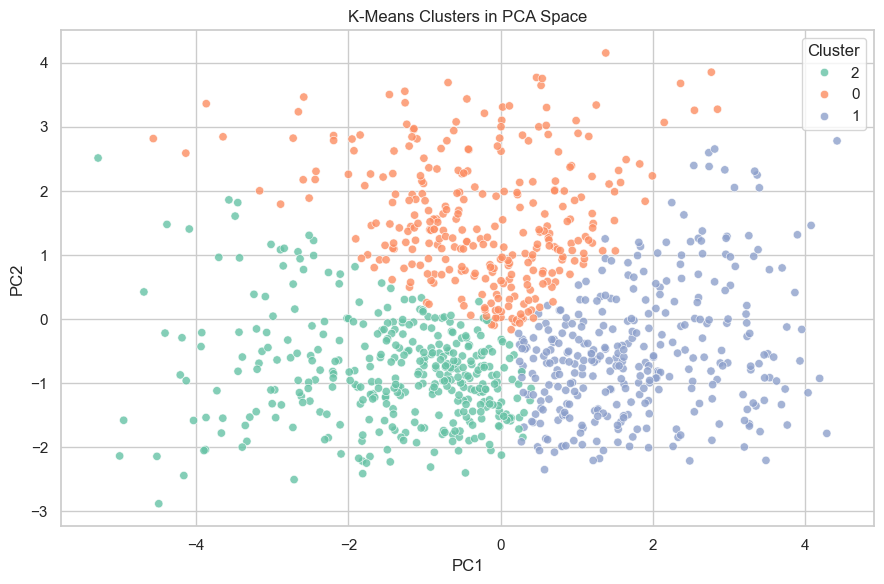

,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,purchase_freq_interaction,engagement_time_interaction,browsing_per_visit,purchase_per_visit,Target_Binary
Cluster,,,,,,,,,,,
0,18.9840,3.6780,"4,926.9450",47.8910,0.7400,40.9760,70.5400,29.4960,13.1800,5.3640,0.1450
1,20.5150,9.1180,"4,853.3300",48.1680,0.4100,24.8130,186.2850,9.0330,5.2820,2.3120,0.3520
2,20.0490,1.5300,"4,991.3160",54.0030,0.3810,25.1470,30.5790,8.0540,25.8720,9.7980,0.3330


In [ ]:
# Clustering with K-Means and PCA visualization
cluster_features = feature_cols_clf
cluster_pipe = Pipeline(
    [('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_cluster = cluster_pipe.fit_transform(df_model[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_cluster)
df_model['Cluster'] = cluster_labels

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plot_df = pd.DataFrame(
    {'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Cluster': df_model['Cluster'].astype(str)})

plt.figure(figsize=(9, 6))
if HAS_SEABORN:
    sns.scatterplot(data=plot_df, x='PC1', y='PC2',
                    hue='Cluster', palette='Set2', alpha=0.8)
else:
    for c in sorted(plot_df['Cluster'].unique()):
        subset = plot_df[plot_df['Cluster'] == c]
        plt.scatter(subset['PC1'], subset['PC2'],
                    label=f'Cluster {c}', alpha=0.8)
    plt.legend()

plt.title('K-Means Clusters in PCA Space')
plt.tight_layout()
plt.show()

cluster_profile = df_model.groupby(
    'Cluster')[cluster_features + ['Target_Binary']].mean().round(3)
display(cluster_profile)

In [ ]:
# Association rule mining with discretized behavior bins
assoc_df = df_model.copy()
bin_cols = ['Purchase_History', 'Transaction_Frequency',
            'Monetary_Value', 'Engagement_Score', 'Time_on_Site']

for col in bin_cols:
    assoc_df[f'{col}_bin'] = pd.qcut(
        assoc_df[col], q=3, labels=['low', 'mid', 'high'])

token_cols = [f'{c}_bin' for c in bin_cols] + ['Customer_Segment']
for col in token_cols:
    assoc_df[col] = col + '=' + assoc_df[col].astype(str)

transactions = assoc_df[token_cols]
one_hot = pd.get_dummies(transactions)

freq = apriori(one_hot, min_support=0.08, use_colnames=True).sort_values(
    'support', ascending=False)
display(freq.head(10))

rules = association_rules(freq, metric='lift', min_threshold=1.1)
if len(rules) == 0:
    print('No association rules met threshold. Lower thresholds if needed.')
else:
    rules = rules[['antecedents', 'consequents', 'support', 'confidence',
                   'lift']].sort_values(['lift', 'confidence'], ascending=False)
    display(rules.head(15))

,support,itemsets
15,0.7180,frozenset({Customer_Segment_Customer_Segment=C...
1,0.3940,frozenset({Purchase_History_bin_Purchase_Histo...
11,0.3390,frozenset({Engagement_Score_bin_Engagement_Sco...
10,0.3370,frozenset({Engagement_Score_bin_Engagement_Sco...
4,0.3340,frozenset({Transaction_Frequency_bin_Transacti...
7,0.3340,frozenset({Monetary_Value_bin_Monetary_Value_b...
13,0.3340,frozenset({Time_on_Site_bin_Time_on_Site_bin=l...
3,0.3330,frozenset({Transaction_Frequency_bin_Transacti...
5,0.3330,frozenset({Transaction_Frequency_bin_Transacti...
6,0.3330,frozenset({Monetary_Value_bin_Monetary_Value_b...


,antecedents,consequents,support,confidence,lift
186,frozenset({Monetary_Value_bin_Monetary_Value_b...,frozenset({Customer_Segment_Customer_Segment=I...,0.0800,0.6838,2.4247
187,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Monetary_Value_bin_Monetary_Value_b...,0.0800,0.2837,2.4247
9,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=I...,0.1820,0.5401,1.9151
8,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Engagement_Score_bin_Engagement_Sco...,0.1820,0.6454,1.9151
10,frozenset({Customer_Segment_Customer_Segment=I...,frozenset({Monetary_Value_bin_Monetary_Value_b...,0.1800,0.6383,1.9111
11,frozenset({Monetary_Value_bin_Monetary_Value_b...,frozenset({Customer_Segment_Customer_Segment=I...,0.1800,0.5389,1.9111
18,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1250,1.0000,1.3928
47,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1150,1.0000,1.3928
75,frozenset({Engagement_Score_bin_Engagement_Sco...,frozenset({Customer_Segment_Customer_Segment=C...,0.1050,1.0000,1.3928
102,frozenset({Monetary_Value_bin_Monetary_Value_b...,frozenset({Customer_Segment_Customer_Segment=C...,0.1010,1.0000,1.3928


## 5) Integrated Final Insights

1. Data quality checks and preprocessing confirmed a stable dataset for analysis.
2. Feature engineering improved predictive signal in both regression and classification tasks.
3. Cross-validation and F1-focused tuning produced more reliable model selection than single-metric evaluation.
4. Clustering revealed interpretable behavior groups that support targeted strategy.
5. Association rules provided pattern-level insights for recommendations and campaign logic.


## 6) Practical Recommendations

- Prioritize retention campaigns for clusters with high engagement but moderate purchase value.
- Use classification outputs to triage customers into segment-specific messaging flows.
- Apply high-lift association rules to guide product bundle suggestions and timing of offers.
- Continue monitoring model performance with periodic retraining as behavior patterns evolve.


## 7) Ethical Considerations

Data privacy:

- Avoid storing direct identifiers in modeling features.
- Restrict access to sensitive customer attributes and apply minimum-necessary-use policies.

Fairness and bias:

- Segment imbalance can bias classifier behavior toward the majority group.
- Using F1, confusion matrix, and ROC helps detect uneven performance.

Responsible use:

- Recommendations should support customer value, not manipulate vulnerable users.
- Include human oversight for high-impact decisions derived from model outputs.


## 8) 5-7 Minute Presentation Outline

- 0:00-0:45: Problem statement, dataset, and objectives
- 0:45-1:45: Data preparation, quality checks, and EDA highlights
- 1:45-3:00: Regression and classification results with key metrics
- 3:00-4:15: Clustering and segment interpretation
- 4:15-5:15: Association rules and real-world applications
- 5:15-6:15: Ethical considerations and risk controls
- 6:15-7:00: Final recommendations and next steps
